In [421]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit

plt.rcParams["font.size"] = 12

In [422]:
def load_trace(filepath):
    """Load oscilloscope trace data from CSV file."""
    with open(filepath, "r", encoding="utf-8-sig") as f:
        lines = f.readlines()

    # Find the line with 'Analog Channels'
    start_idx = None
    for i, line in enumerate(lines):
        if "Analog Channels" in line:
            start_idx = i + 2  # Skip header line
            break

    if start_idx is None:
        raise ValueError(f"Could not find 'Analog Channels' in {filepath}")

    # Read the data
    data = []
    for line in lines[start_idx:]:
        parts = line.strip().split(",")
        if len(parts) >= 3 and parts[0].strip().isdigit():
            time = float(parts[1])
            voltage = float(parts[2])
            data.append([time, voltage])

    df = pd.DataFrame(data, columns=["time", "voltage"])
    return df

In [423]:
# Load all traces
trace_dirs = {
    "CuSO4": "trace_processing/t2star_traces/CuSO4_Responses",
    "CuSO4-H2O": "trace_processing/t2star_traces/CuSO4H2O_Responses",
    "Glycerin": "trace_processing/t2star_traces/Glycerin_Responses_Spandan",
    "H2O": "trace_processing/t2star_traces/H2O_Responses",
    "Polystyrene": "trace_processing/t2star_traces/Polystyrene_Responses_Spandan",
    "PTFE": "trace_processing/t2star_traces/PTFE_Responses_Spandan",
}

all_traces = []

for substance, dir_path in trace_dirs.items():
    full_path = Path(dir_path)
    csv_files = list(full_path.glob("*.csv"))

    for csv_file in csv_files:
        try:
            trace_df = load_trace(csv_file)
            trace_df["substance"] = substance
            trace_df["filename"] = csv_file.name
            all_traces.append(trace_df)
            print(f"Loaded {substance}: {csv_file.name}")
        except Exception as e:
            print(f"Error loading {csv_file}: {e}")

# Combine all traces
traces_df = pd.concat(all_traces, ignore_index=True)
print(f"\nTotal traces loaded: {len(all_traces)}")
print(f"Total data points: {len(traces_df)}")

Loaded CuSO4: CuSO4_B4300 2026-02-25 14-05-10.csv
Loaded CuSO4: CuSO4_B4190 2026-02-25 13-56-43.csv
Loaded CuSO4: CuSO4_B3660 2026-02-25 14-15-12.csv
Loaded CuSO4: CuSO4_B3850 response 2026-02-25 13-09-11.csv
Loaded CuSO4: CuSO4_B3960 2026-02-25 13-24-18.csv
Loaded CuSO4-H2O: CuSO4H2O_B3600 2026-02-25 14-36-48.csv
Loaded CuSO4-H2O: CuSO4H2O_B3900 2026-02-25 14-25-53.csv
Loaded CuSO4-H2O: CuSO4H2O_B4310 2026-02-25 14-31-24.csv
Loaded CuSO4-H2O: CuSO4H2O_B4160 2026-02-25 14-28-00.csv
Loaded CuSO4-H2O: CuSO4H2O_B3670 2026-02-25 14-23-33.csv
Loaded Glycerin: GlycerinNew_B4150 2026-03-04 13-49-19.csv
Loaded Glycerin: GlycerinNew_4050 2026-03-04 13-47-09.csv
Loaded Glycerin: GlycerinNew_B3750 2026-03-04 13-33-33.csv
Loaded Glycerin: Glycerin_B3810 2026-03-04 13-05-23.csv
Loaded Glycerin: Glycerin_B3800 2026-03-04 12-52-34.csv
Loaded Glycerin: GlycerinNew_B3850 2026-03-04 13-31-27.csv
Loaded Glycerin: GlycerinNew_B3950 2026-03-04 13-36-40.csv
Loaded H2O: H2O_B4220 2026-02-25 14-48-57.csv
Load

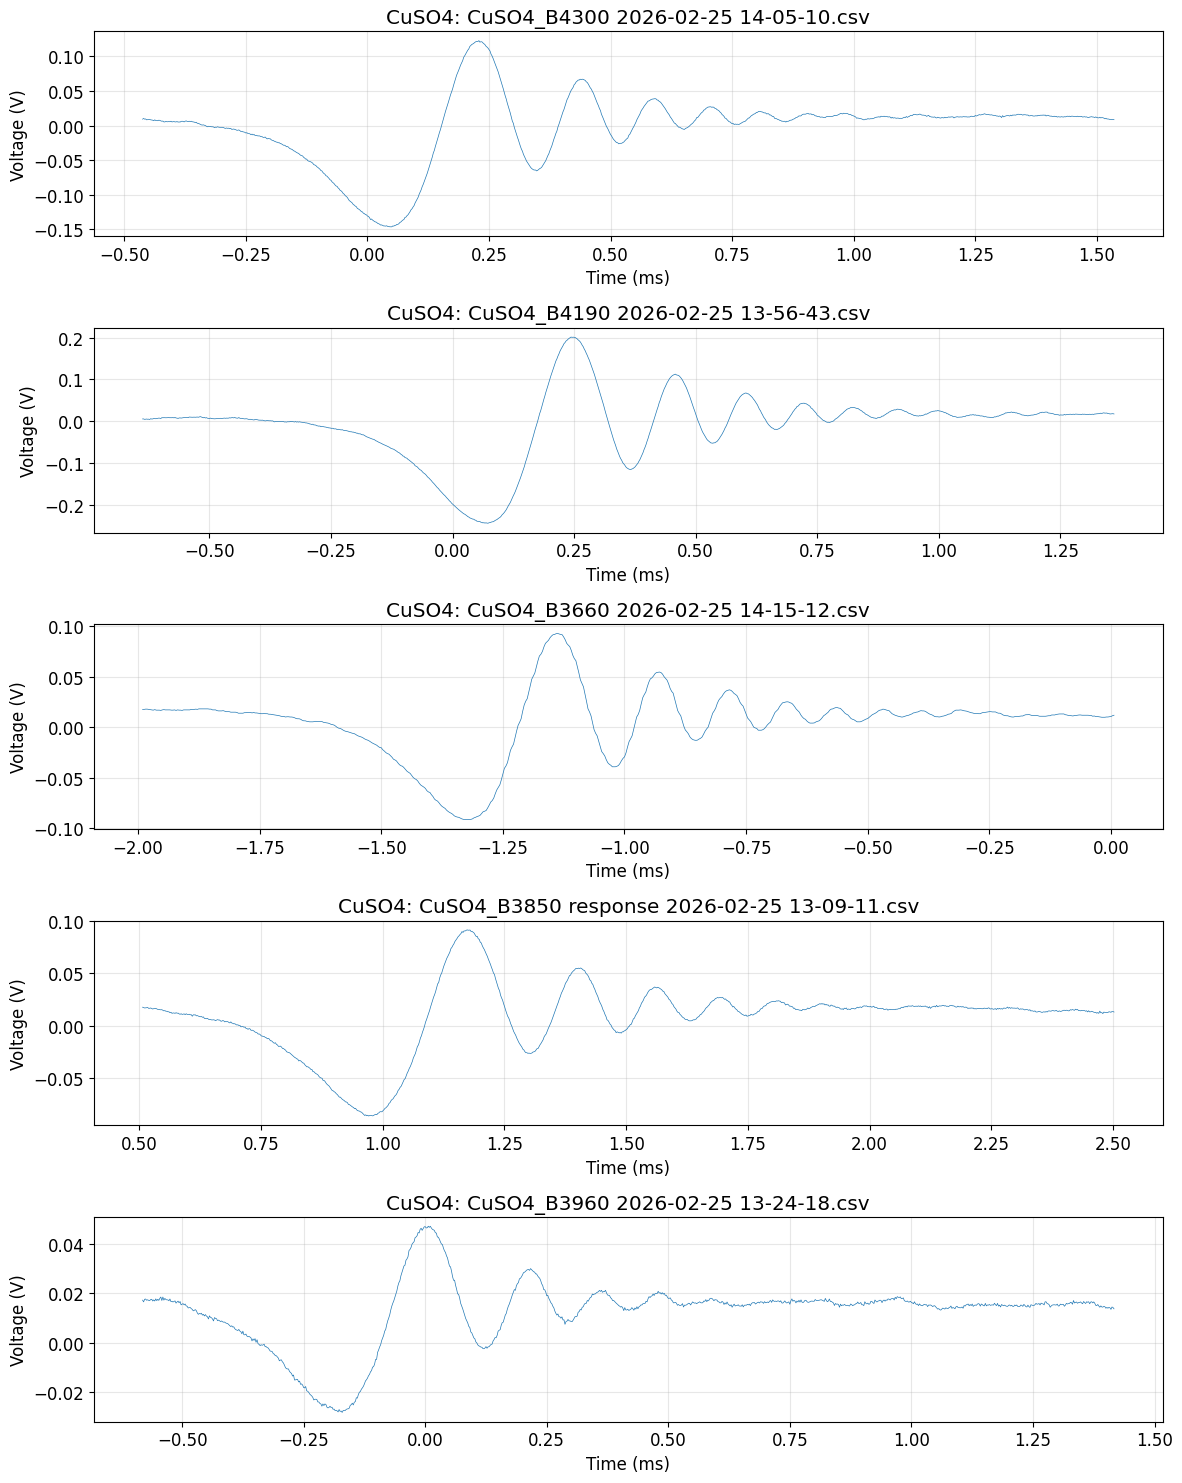

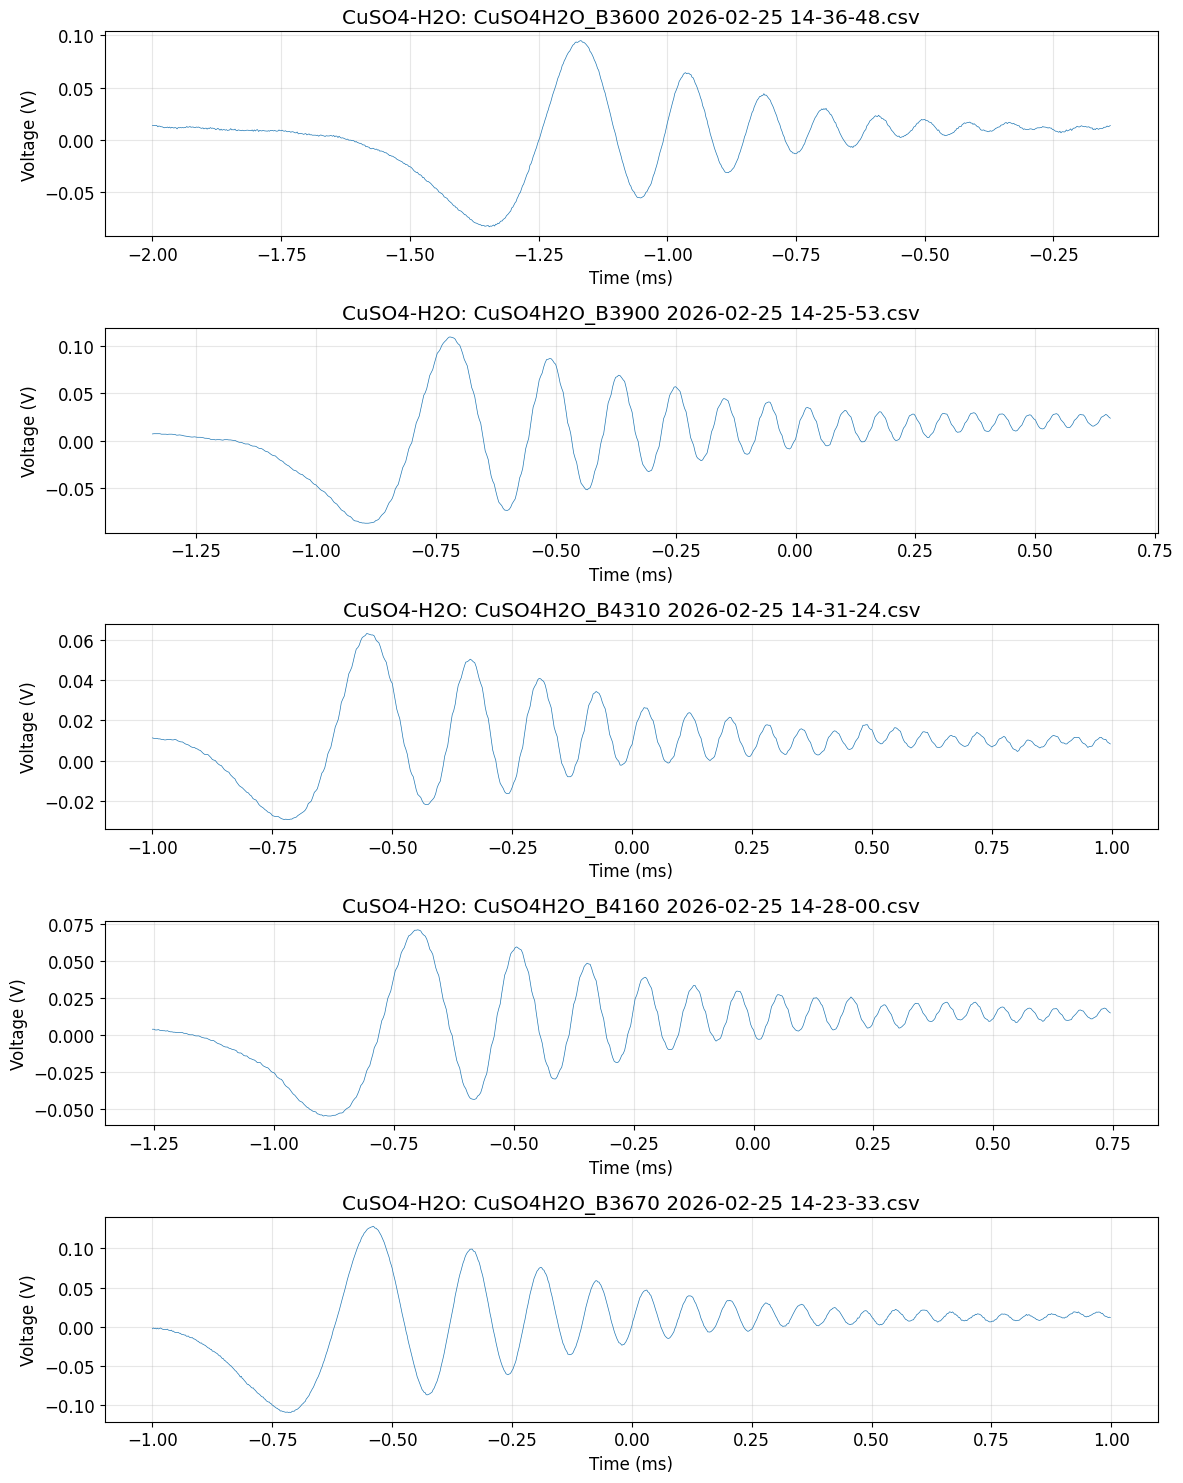

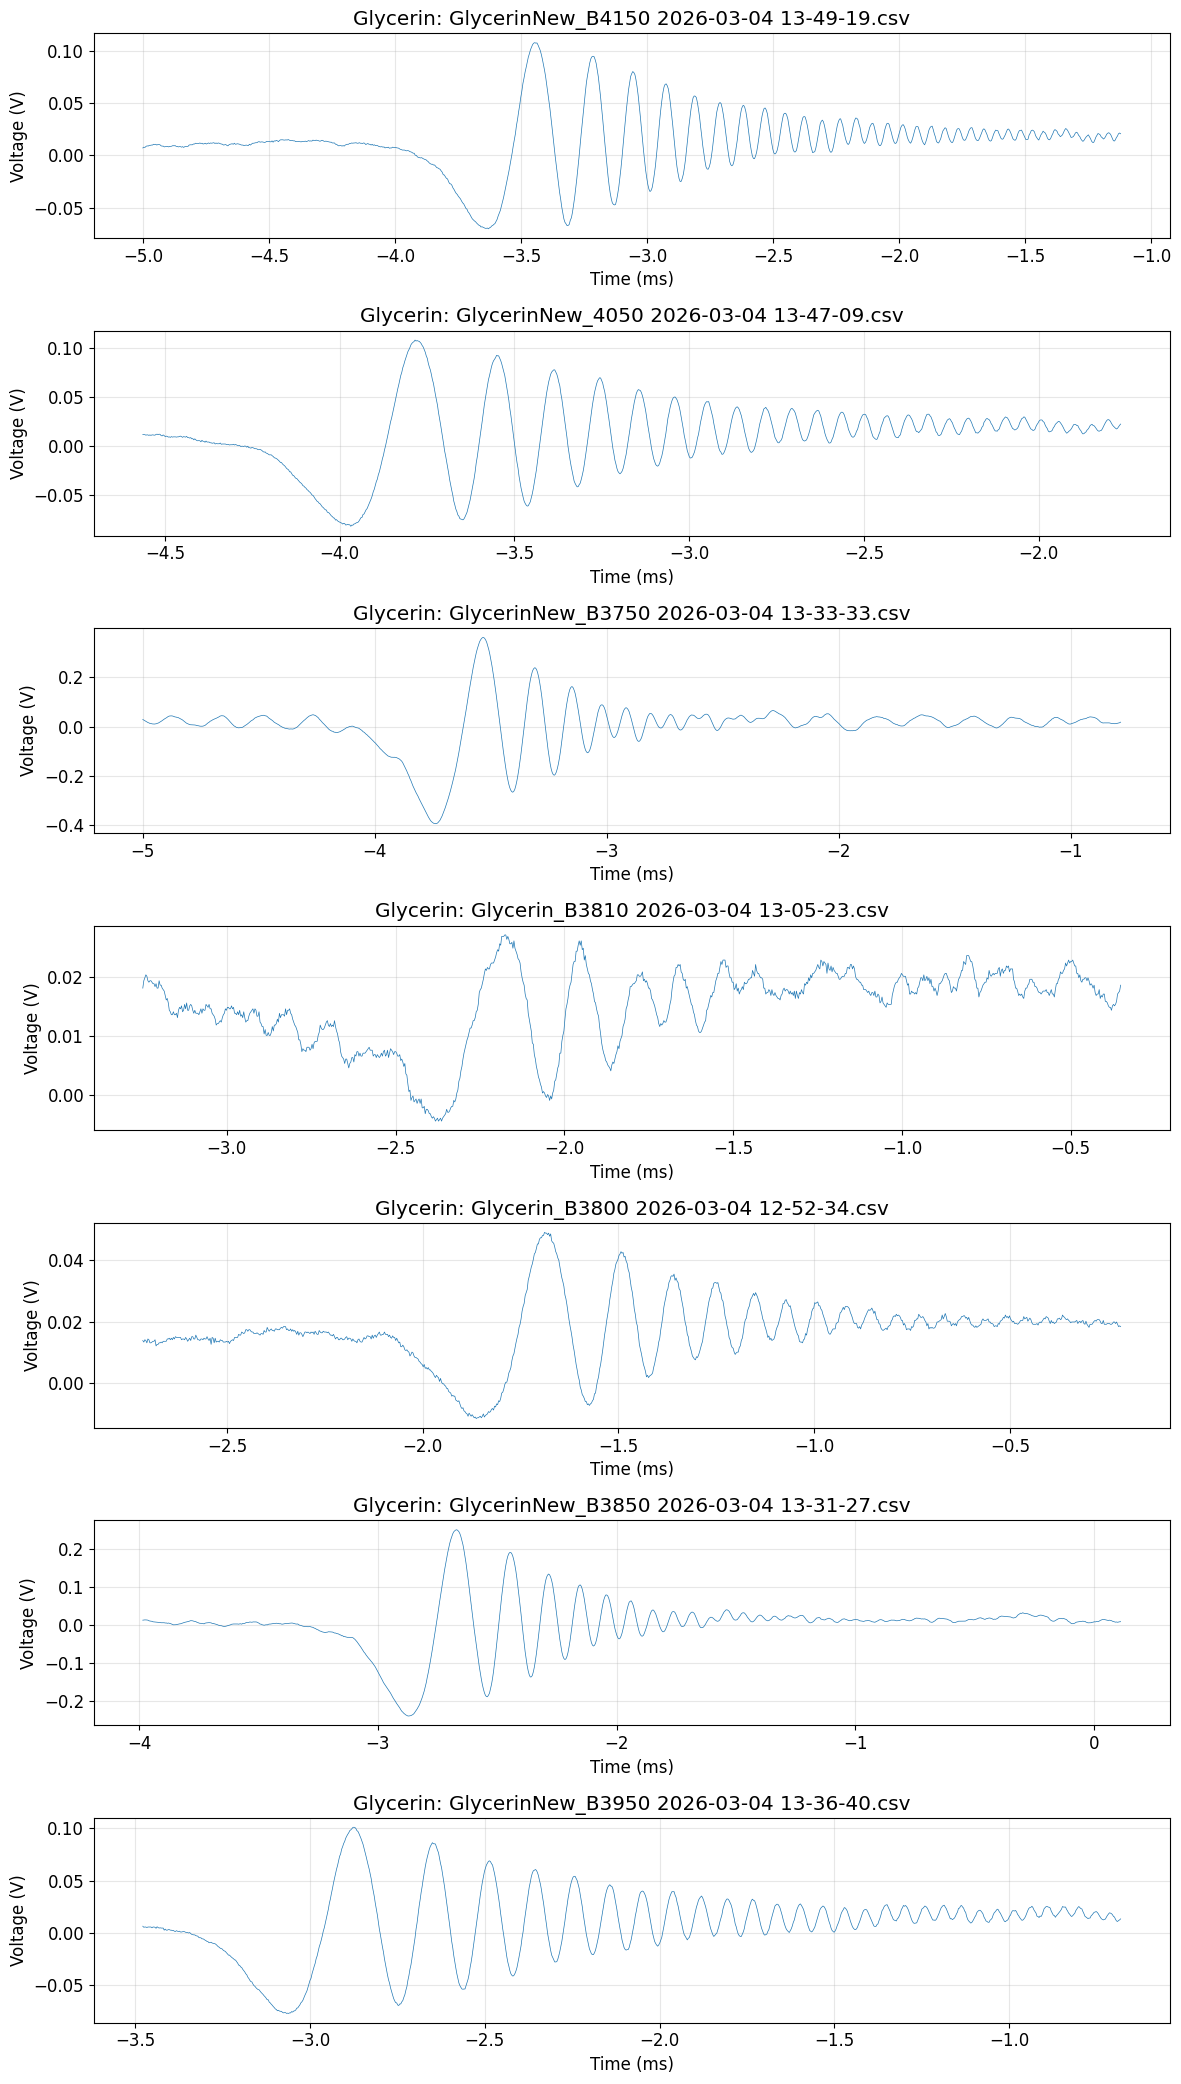

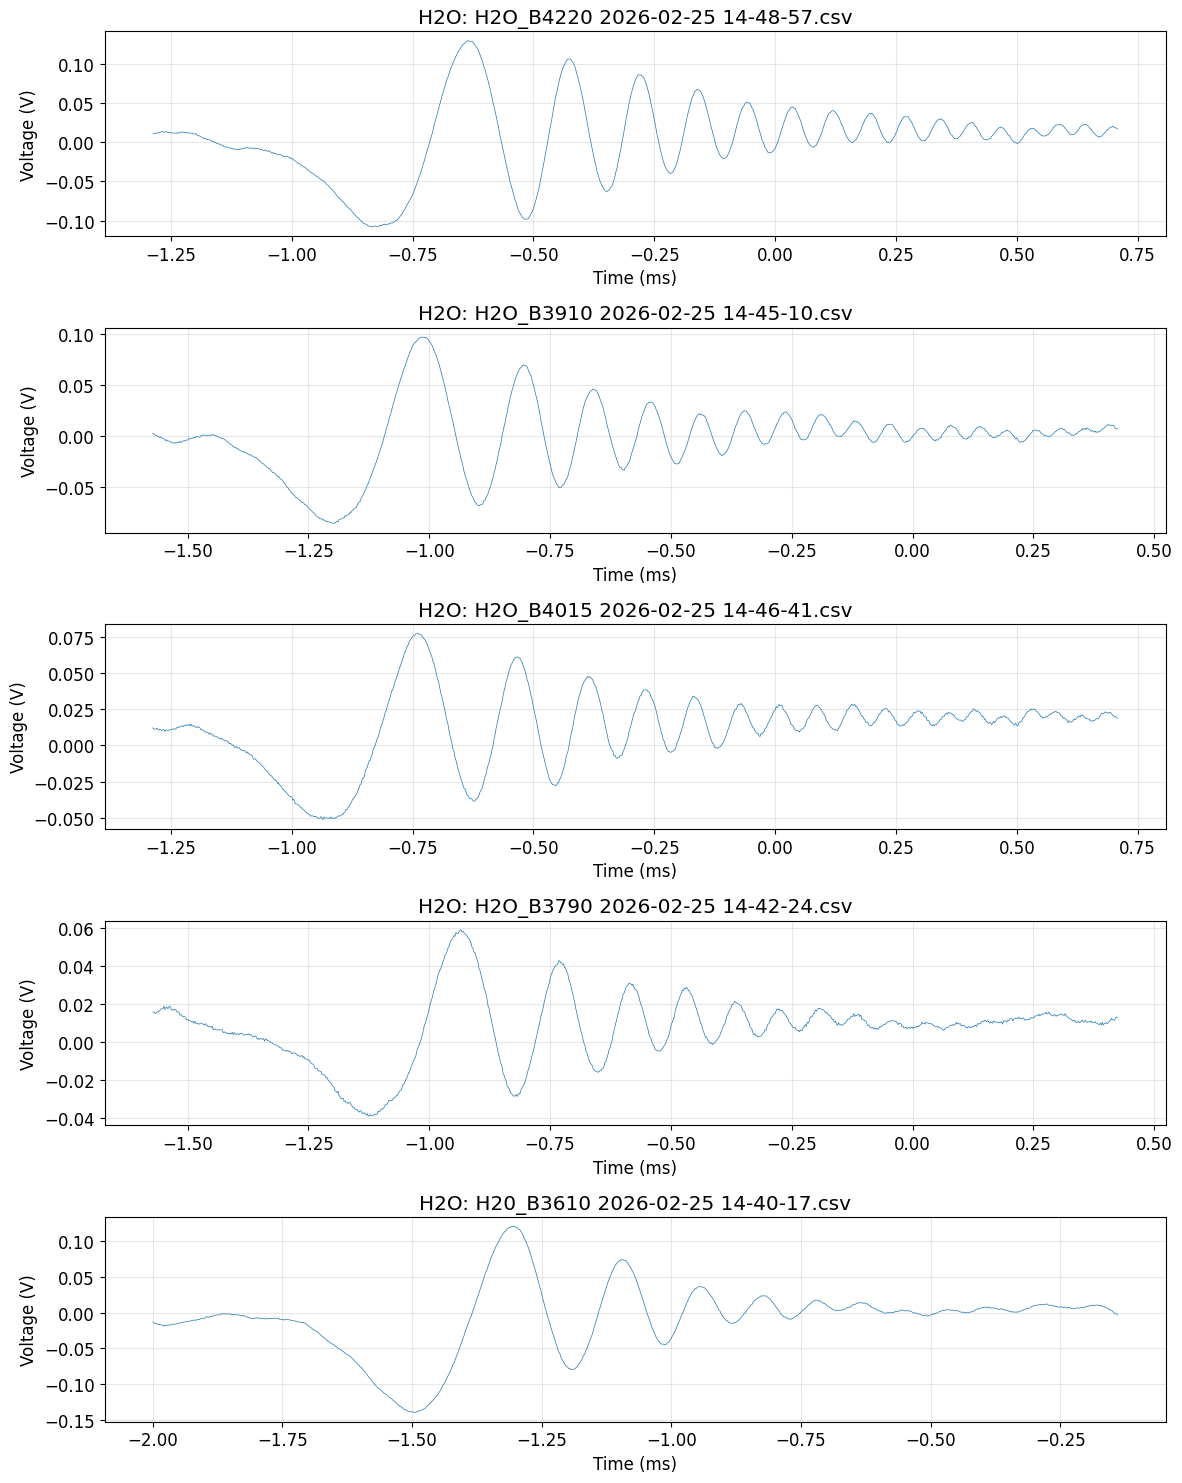

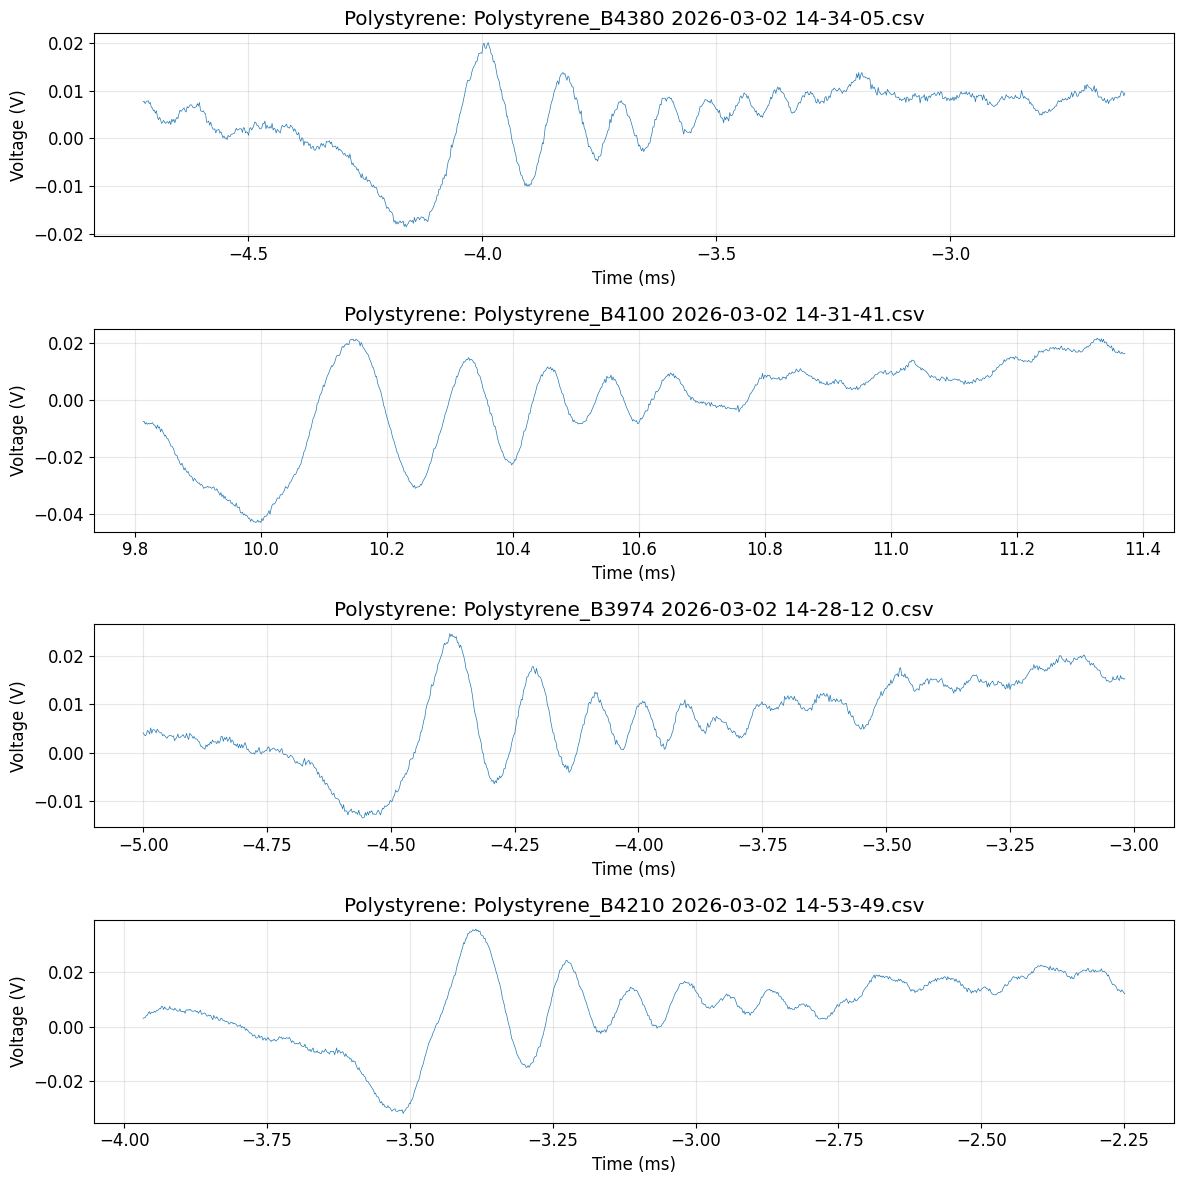

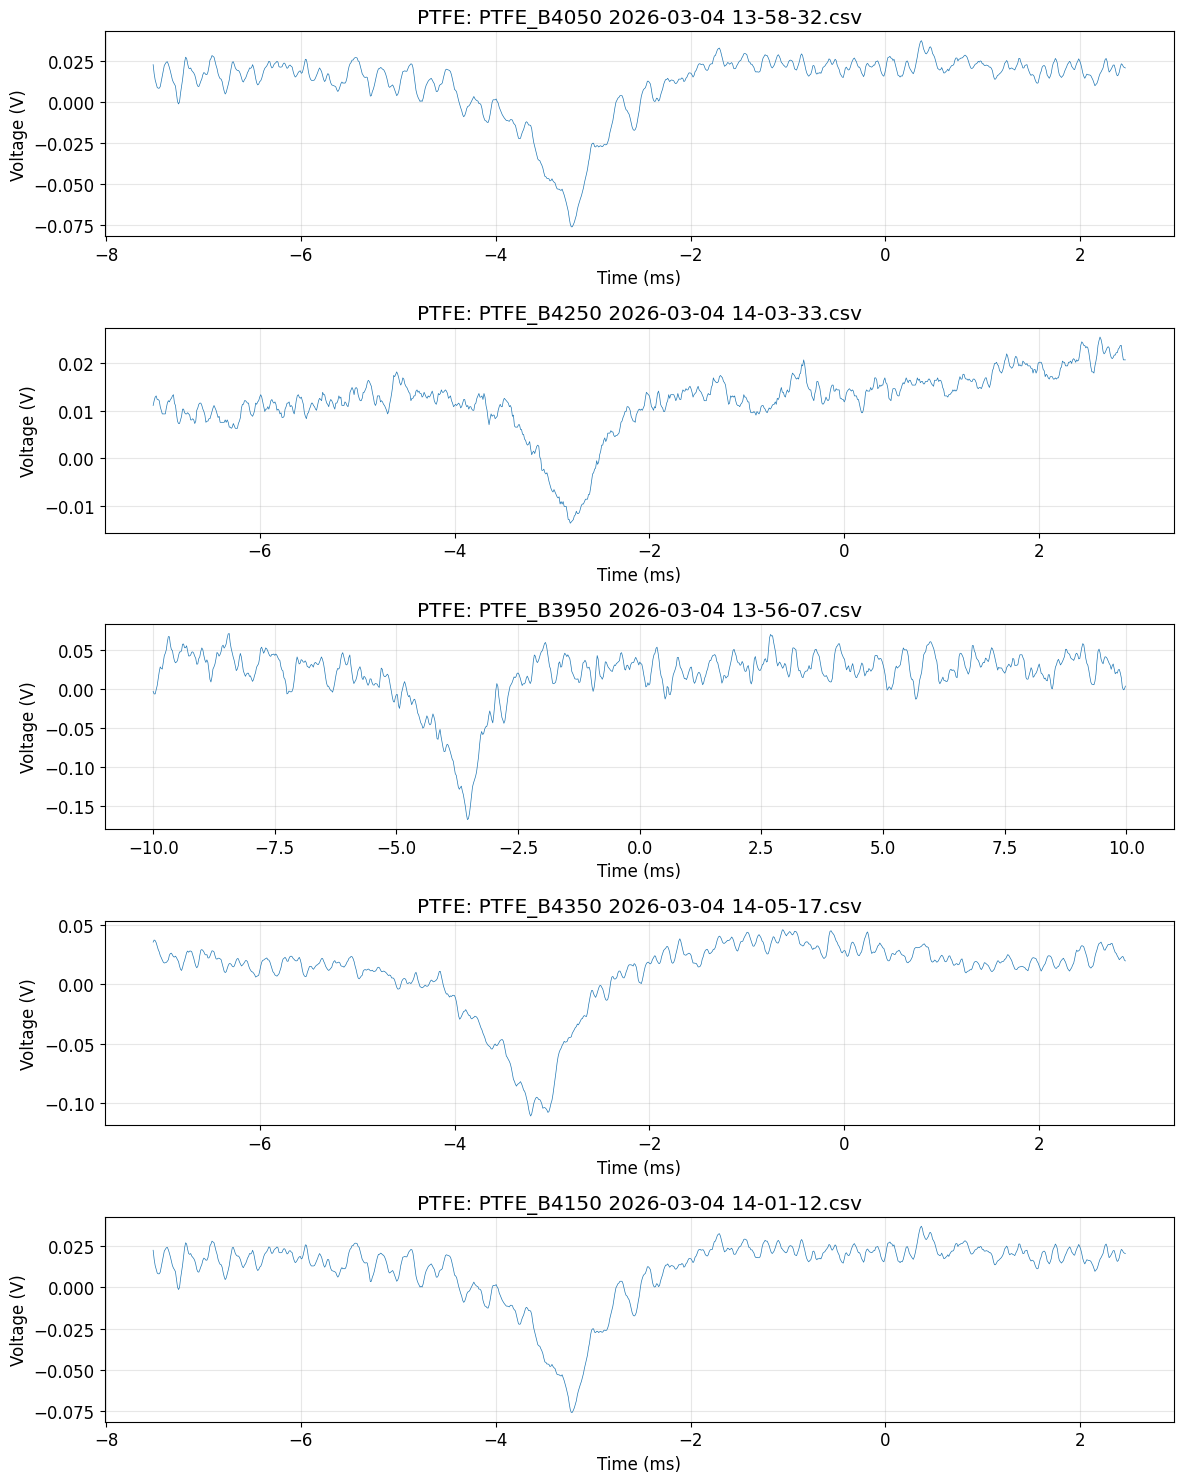

In [424]:
# Plot raw traces for each substance
substances = traces_df["substance"].unique()

for substance in substances:
    substance_data = traces_df[traces_df["substance"] == substance]
    files = substance_data["filename"].unique()

    n_files = len(files)
    fig, axes = plt.subplots(n_files, 1, figsize=(12, 3 * n_files))
    if n_files == 1:
        axes = [axes]

    for i, filename in enumerate(files):
        file_data = substance_data[substance_data["filename"] == filename]
        axes[i].plot(file_data["time"] * 1e3, file_data["voltage"], linewidth=0.5)
        axes[i].set_xlabel("Time (ms)")
        axes[i].set_ylabel("Voltage (V)")
        axes[i].set_title(f"{substance}: {filename}")
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Configuration dictionary for focused trace analysis

trace_config = {
    "CuSO4": {
        "trace_index": 1,  # Which trace file to use (0-indexed)
        "time_range": (0, 1.0),  # Time interval in milliseconds (start, end)
        "vertical_shift": -0.02,  # Vertical shift in volts
        "lowpass_freq": None,  # Low-pass filter frequency in Hz (or None to disable)
    },
    "CuSO4-H2O": {
        "trace_index": 0,
        "time_range": (-1.4, -0.25),
        "vertical_shift": -0.012,
        "lowpass_freq": None,
    },
    "H2O": {
        "trace_index": 2,
        "time_range": (-1, 0.4),
        "vertical_shift": -0.019,
        "lowpass_freq": None,
    },
    "Polystyrene": {
        "trace_index": 3,
        "time_range": (-3.45, -2.75),
        "vertical_shift": -0.01,
        "lowpass_freq": 24000,
    },
    "Glycerin": {
        "trace_index": 1,
        "time_range": (-3.8, -1.8),
        "vertical_shift": -0.02,
        "lowpass_freq": None,
    },
    "PTFE": {
        "trace_index": 1,
        "time_range": (-2.75, 0),
        "vertical_shift": -0.015,
        "lowpass_freq": None,
    },
}

# Display available traces for each substance
print("Available traces by substance:")
print("=" * 60)
substances = traces_df["substance"].unique()
for substance in substances:
    substance_data = traces_df[traces_df["substance"] == substance]
    files = substance_data["filename"].unique()
    print(f"\n{substance}:")
    for i, filename in enumerate(files):
        print(f"  [{i}] {filename}")

Available traces by substance:

CuSO4:
  [0] CuSO4_B4300 2026-02-25 14-05-10.csv
  [1] CuSO4_B4190 2026-02-25 13-56-43.csv
  [2] CuSO4_B3660 2026-02-25 14-15-12.csv
  [3] CuSO4_B3850 response 2026-02-25 13-09-11.csv
  [4] CuSO4_B3960 2026-02-25 13-24-18.csv

CuSO4-H2O:
  [0] CuSO4H2O_B3600 2026-02-25 14-36-48.csv
  [1] CuSO4H2O_B3900 2026-02-25 14-25-53.csv
  [2] CuSO4H2O_B4310 2026-02-25 14-31-24.csv
  [3] CuSO4H2O_B4160 2026-02-25 14-28-00.csv
  [4] CuSO4H2O_B3670 2026-02-25 14-23-33.csv

Glycerin:
  [0] GlycerinNew_B4150 2026-03-04 13-49-19.csv
  [1] GlycerinNew_4050 2026-03-04 13-47-09.csv
  [2] GlycerinNew_B3750 2026-03-04 13-33-33.csv
  [3] Glycerin_B3810 2026-03-04 13-05-23.csv
  [4] Glycerin_B3800 2026-03-04 12-52-34.csv
  [5] GlycerinNew_B3850 2026-03-04 13-31-27.csv
  [6] GlycerinNew_B3950 2026-03-04 13-36-40.csv

H2O:
  [0] H2O_B4220 2026-02-25 14-48-57.csv
  [1] H2O_B3910 2026-02-25 14-45-10.csv
  [2] H2O_B4015 2026-02-25 14-46-41.csv
  [3] H2O_B3790 2026-02-25 14-42-24.csv

In [426]:
def lowpass_filter(time, voltage, cutoff_freq, order=4):
    """Apply Butterworth low-pass filter to the signal.

    Parameters:
    -----------
    time : array
        Time values in seconds
    voltage : array
        Voltage values
    cutoff_freq : float
        Cutoff frequency in Hz
    order : int
        Filter order (default: 4)

    Returns:
    --------
    filtered_voltage : array
        Filtered voltage values
    """
    # Calculate sampling frequency
    dt = np.mean(np.diff(time))
    fs = 1.0 / dt
    nyquist = fs / 2.0

    # Normalize cutoff frequency
    normalized_cutoff = cutoff_freq / nyquist

    if normalized_cutoff >= 1.0:
        print(
            f"  Warning: Cutoff frequency {cutoff_freq} Hz is too high (Nyquist: {nyquist:.1f} Hz)"
        )
        print(f"  Skipping low-pass filter")
        return voltage

    # Design Butterworth filter
    b, a = butter(order, normalized_cutoff, btype="low", analog=False)

    # Apply filter (filtfilt for zero-phase filtering)
    filtered_voltage = filtfilt(b, a, voltage)

    return filtered_voltage


def exponential_decay(t, A, T2star, offset):
    """Exponential decay function."""
    return A * np.exp(-t / T2star) + offset


def extract_envelope(time, voltage, min_peak_height=None):
    """Extract envelope by finding local maxima."""
    abs_voltage = np.abs(voltage)

    # Check for empty array
    if len(abs_voltage) == 0:
        raise ValueError("No data points in the specified time range")

    if min_peak_height is None:
        min_peak_height = 0.1 * np.max(abs_voltage)

    peaks, _ = find_peaks(abs_voltage, height=min_peak_height, distance=5)

    # Check if peaks were found
    if len(peaks) == 0:
        # Lower the threshold and try again
        min_peak_height = 0.05 * np.max(abs_voltage)
        peaks, _ = find_peaks(abs_voltage, height=min_peak_height, distance=3)

        if len(peaks) == 0:
            raise ValueError(
                "No peaks found in signal. Try adjusting time_range or vertical_shift"
            )

    return time[peaks], abs_voltage[peaks]


Processing CuSO4...
  Original time range: -0.638 to 1.360 ms
  Requested time range: 0.000 to 1.000 ms
  Data points after filtering: 480
  Found 8 envelope peaks
  T2* = 0.911 ± 0.222 ms


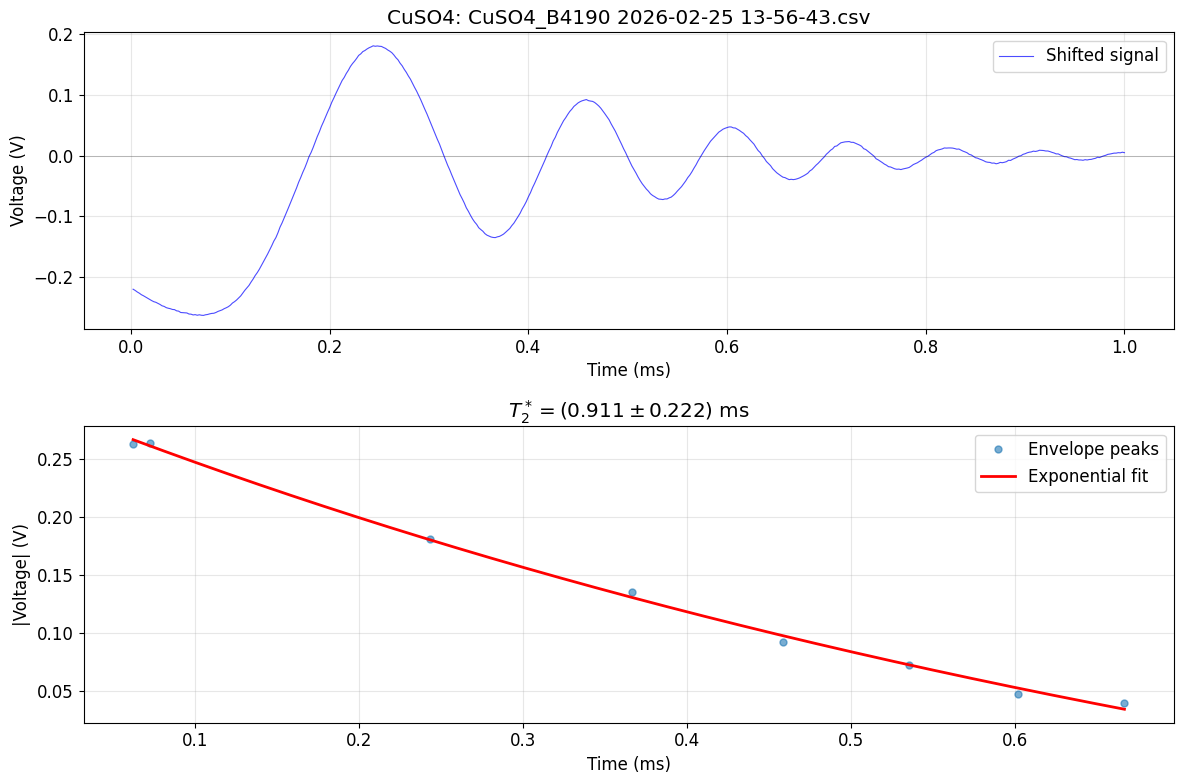


Processing CuSO4-H2O...
  Original time range: -2.000 to -0.140 ms
  Requested time range: -1.400 to -0.250 ms
  Data points after filtering: 552
  Found 13 envelope peaks
  T2* = 734.248 ± 176283.592 ms


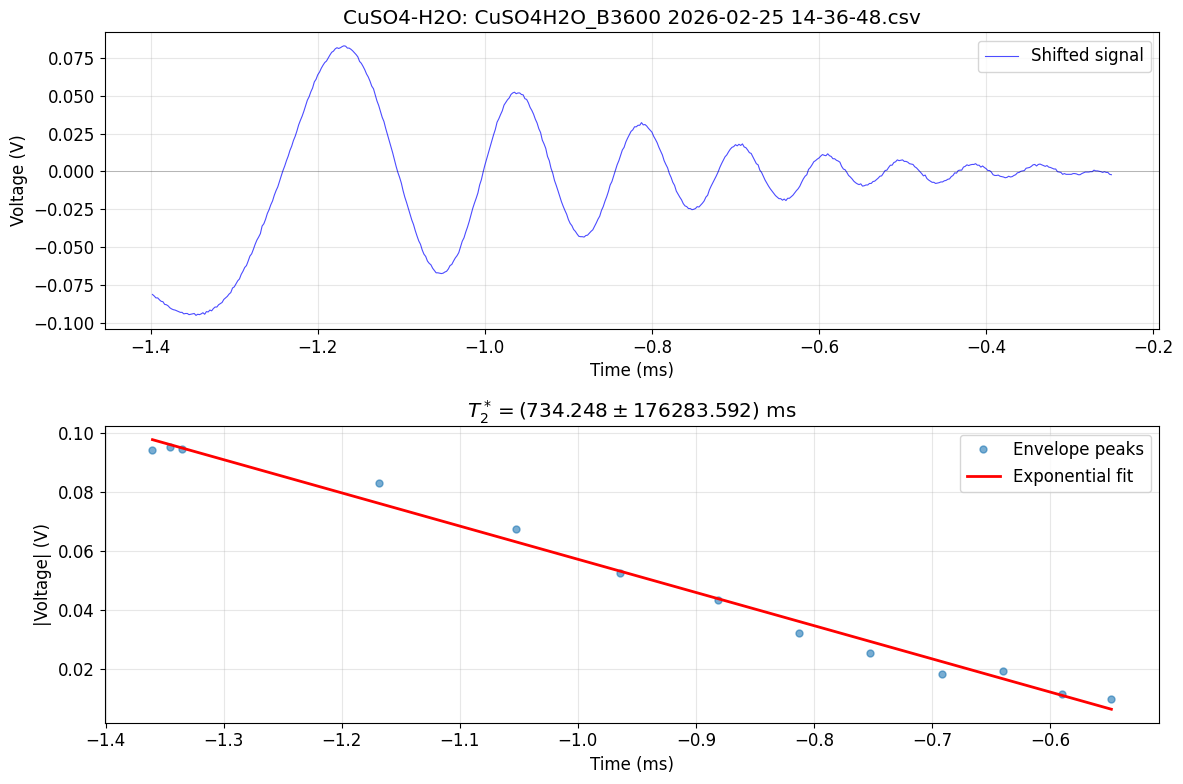


Processing H2O...
  Original time range: -1.288 to 0.708 ms
  Requested time range: -1.000 to 0.400 ms
  Data points after filtering: 672
  Found 22 envelope peaks
  T2* = 2.045 ± 1.235 ms


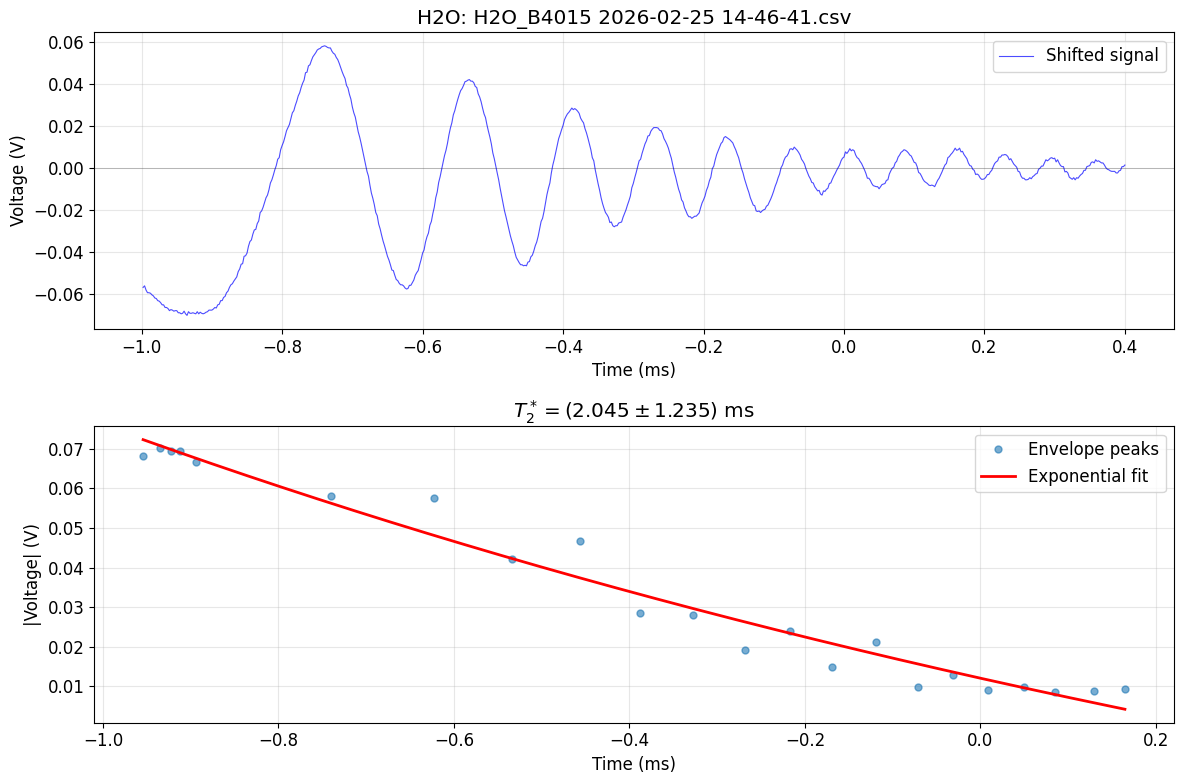


Processing Polystyrene...
  Original time range: -3.967 to -2.249 ms
  Requested time range: -3.450 to -2.750 ms
  Data points after filtering: 391
  Applying low-pass filter at 24000 Hz
  Found 12 envelope peaks
  T2* = 0.220 ± 0.085 ms


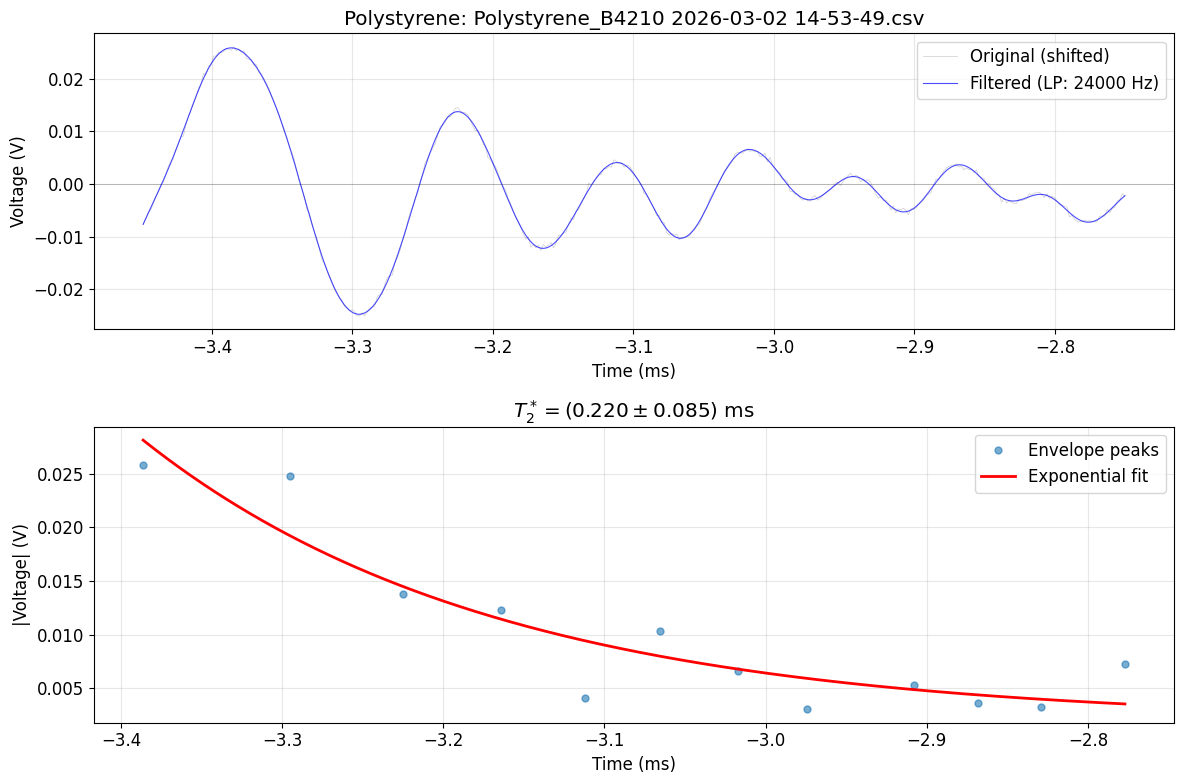


Processing Glycerin...
  Original time range: -4.563 to -1.766 ms
  Requested time range: -3.800 to -1.800 ms
  Data points after filtering: 686
  Found 32 envelope peaks
  T2* = 0.811 ± 0.121 ms


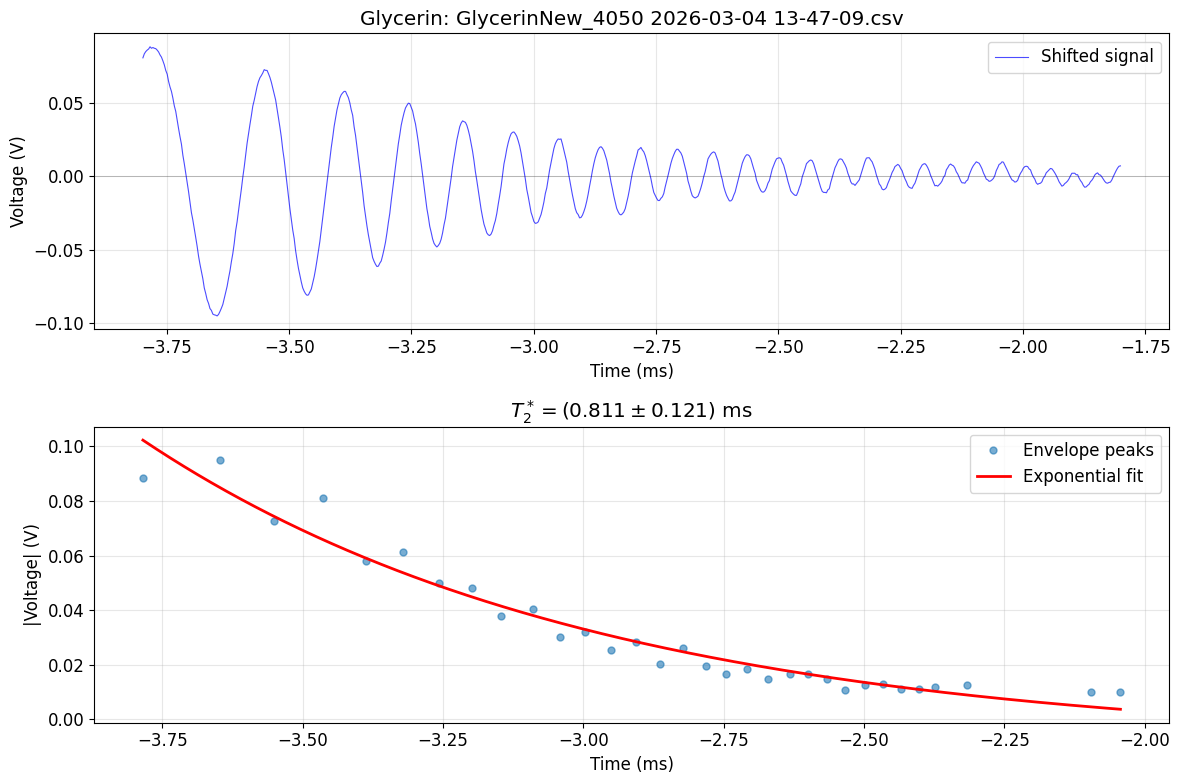


Processing PTFE...
  Original time range: -7.094 to 2.885 ms
  Requested time range: -2.750 to 0.000 ms
  Data points after filtering: 264
  Applying low-pass filter at 300000 Hz
  Skipping low-pass filter
  T2* = 0.298 ± 0.013 ms


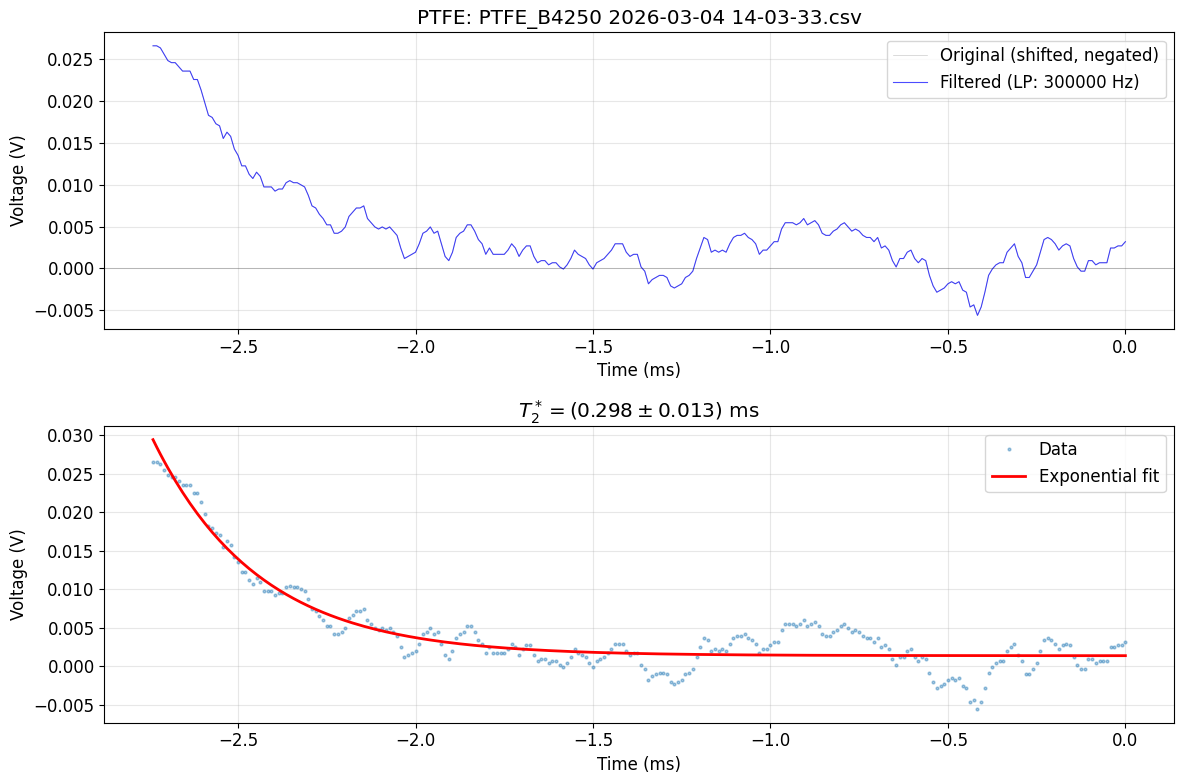


T2* Results Summary:
  substance                                  filename  T2star_ms  sigma_T2star_ms
      CuSO4       CuSO4_B4190 2026-02-25 13-56-43.csv   0.911384         0.221939
  CuSO4-H2O    CuSO4H2O_B3600 2026-02-25 14-36-48.csv 734.247576    176283.592434
        H2O         H2O_B4015 2026-02-25 14-46-41.csv   2.045412         1.235348
Polystyrene Polystyrene_B4210 2026-03-02 14-53-49.csv   0.219587         0.085286
   Glycerin  GlycerinNew_4050 2026-03-04 13-47-09.csv   0.811155         0.121360
       PTFE        PTFE_B4250 2026-03-04 14-03-33.csv   0.297953         0.013197


In [427]:
# Fit T2* for selected traces
t2star_results = []

for substance, config in trace_config.items():
    print(f"\nProcessing {substance}...")

    # Get the specified trace
    substance_data = traces_df[traces_df["substance"] == substance]
    files = substance_data["filename"].unique()

    if config["trace_index"] >= len(files):
        print(
            f"  Warning: trace_index {config['trace_index']} out of range for {substance}"
        )
        continue

    selected_file = files[config["trace_index"]]
    file_data = substance_data[substance_data["filename"] == selected_file]

    # Extract time and voltage
    time = file_data["time"].values
    voltage = file_data["voltage"].values

    print(f"  Original time range: {time.min() * 1e3:.3f} to {time.max() * 1e3:.3f} ms")
    print(
        f"  Requested time range: {config['time_range'][0]:.3f} to {config['time_range'][1]:.3f} ms"
    )

    # Convert time_range from ms to seconds
    time_range_s = (config["time_range"][0] * 1e-3, config["time_range"][1] * 1e-3)

    # Apply time range filter
    time_mask = (time >= time_range_s[0]) & (time <= time_range_s[1])
    time_filtered = time[time_mask]
    voltage_filtered = voltage[time_mask]

    print(f"  Data points after filtering: {len(time_filtered)}")

    if len(time_filtered) == 0:
        print(f"  ERROR: No data points in specified time range!")
        continue

    # Apply vertical shift
    voltage_shifted = voltage_filtered + config["vertical_shift"]

    # Apply low-pass filter if specified
    if config["lowpass_freq"] is not None:
        print(f"  Applying low-pass filter at {config['lowpass_freq']} Hz")
        voltage_processed = lowpass_filter(
            time_filtered, voltage_shifted, config["lowpass_freq"]
        )
    else:
        voltage_processed = voltage_shifted

    try:
        # PTFE is critically damped - fit exponential directly to the signal
        if substance == "PTFE":
            # Negate the signal for PTFE
            voltage_processed = -voltage_processed

            # Normalize time to start at 0 for fitting
            time_normalized = time_filtered - time_filtered[0]

            # Initial guess for fitting
            A0 = np.max(voltage_processed) - np.min(voltage_processed)
            T2star0 = 0.0005  # 0.5 ms initial guess
            offset0 = np.min(voltage_processed)

            # Fit exponential decay directly to the signal
            popt, pcov = curve_fit(
                exponential_decay,
                time_normalized,
                voltage_processed,
                p0=[A0, T2star0, offset0],
                bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=10000,
            )

            A, T2star, offset = popt
            sigma_T2star = np.sqrt(pcov[1, 1])

            print(f"  T2* = {T2star * 1e3:.3f} ± {sigma_T2star * 1e3:.3f} ms")

            # Store results
            t2star_results.append(
                {
                    "substance": substance,
                    "filename": selected_file,
                    "T2star_ms": T2star * 1e3,
                    "sigma_T2star_ms": sigma_T2star * 1e3,
                }
            )

            # Plot results
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

            # Raw signal (show both original and filtered if filter was applied)
            if config["lowpass_freq"] is not None:
                ax1.plot(
                    time_filtered * 1e3,
                    -voltage_shifted,
                    linewidth=0.5,
                    alpha=0.4,
                    label="Original (shifted, negated)",
                    color="gray",
                )
                ax1.plot(
                    time_filtered * 1e3,
                    voltage_processed,
                    linewidth=0.8,
                    alpha=0.7,
                    label=f"Filtered (LP: {config['lowpass_freq']} Hz)",
                    color="blue",
                )
            else:
                ax1.plot(
                    time_filtered * 1e3,
                    voltage_processed,
                    linewidth=0.8,
                    alpha=0.7,
                    label="Shifted, negated signal",
                    color="blue",
                )

            ax1.set_xlabel("Time (ms)")
            ax1.set_ylabel("Voltage (V)")
            ax1.set_title(f"{substance}: {selected_file}")
            ax1.grid(True, alpha=0.3)
            ax1.legend()
            ax1.axhline(y=0, color="k", linewidth=0.5, alpha=0.3)

            # Direct exponential fit
            voltage_fit = exponential_decay(time_normalized, A, T2star, offset)
            ax2.plot(
                time_filtered * 1e3,
                voltage_processed,
                "o",
                markersize=2,
                alpha=0.4,
                label="Data",
            )
            ax2.plot(
                time_filtered * 1e3,
                voltage_fit,
                "r-",
                linewidth=2,
                label="Exponential fit",
            )

            ax2.set_xlabel("Time (ms)")
            ax2.set_ylabel("Voltage (V)")
            ax2.set_title(
                f"$T_2^* = ({T2star * 1e3:.3f} \\pm {sigma_T2star * 1e3:.3f})$ ms"
            )
            ax2.grid(True, alpha=0.3)
            ax2.legend()

            plt.tight_layout()
            plt.show()

        else:
            # Underdamped oscillation - extract envelope from local maxima
            envelope_time, envelope_voltage = extract_envelope(
                time_filtered, voltage_processed
            )
            print(f"  Found {len(envelope_time)} envelope peaks")

            # Initial guess for fitting
            A0 = np.max(envelope_voltage)
            T2star0 = 0.001  # 1 ms
            offset0 = np.min(envelope_voltage)

            # Fit exponential decay
            popt, pcov = curve_fit(
                exponential_decay,
                envelope_time,
                envelope_voltage,
                p0=[A0, T2star0, offset0],
                bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=10000,
            )

            A, T2star, offset = popt
            sigma_T2star = np.sqrt(pcov[1, 1])

            print(f"  T2* = {T2star * 1e3:.3f} ± {sigma_T2star * 1e3:.3f} ms")

            # Store results
            t2star_results.append(
                {
                    "substance": substance,
                    "filename": selected_file,
                    "T2star_ms": T2star * 1e3,
                    "sigma_T2star_ms": sigma_T2star * 1e3,
                }
            )

            # Plot results
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

            # Raw signal (show both original and filtered if filter was applied)
            if config["lowpass_freq"] is not None:
                ax1.plot(
                    time_filtered * 1e3,
                    voltage_shifted,
                    linewidth=0.5,
                    alpha=0.4,
                    label="Original (shifted)",
                    color="gray",
                )
                ax1.plot(
                    time_filtered * 1e3,
                    voltage_processed,
                    linewidth=0.8,
                    alpha=0.7,
                    label=f"Filtered (LP: {config['lowpass_freq']} Hz)",
                    color="blue",
                )
            else:
                ax1.plot(
                    time_filtered * 1e3,
                    voltage_processed,
                    linewidth=0.8,
                    alpha=0.7,
                    label="Shifted signal",
                    color="blue",
                )

            ax1.set_xlabel("Time (ms)")
            ax1.set_ylabel("Voltage (V)")
            ax1.set_title(f"{substance}: {selected_file}")
            ax1.grid(True, alpha=0.3)
            ax1.legend()
            ax1.axhline(y=0, color="k", linewidth=0.5, alpha=0.3)

            # Envelope and fit
            ax2.plot(
                envelope_time * 1e3,
                envelope_voltage,
                "o",
                markersize=5,
                alpha=0.6,
                label="Envelope peaks",
            )

            time_fit = np.linspace(envelope_time.min(), envelope_time.max(), 1000)
            voltage_fit = exponential_decay(time_fit, A, T2star, offset)
            ax2.plot(
                time_fit * 1e3, voltage_fit, "r-", linewidth=2, label="Exponential fit"
            )

            ax2.set_xlabel("Time (ms)")
            ax2.set_ylabel("|Voltage| (V)")
            ax2.set_title(
                f"$T_2^* = ({T2star * 1e3:.3f} \\pm {sigma_T2star * 1e3:.3f})$ ms"
            )
            ax2.grid(True, alpha=0.3)
            ax2.legend()

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"  ERROR fitting {substance}: {e}")

# Summary table
if len(t2star_results) > 0:
    t2star_df = pd.DataFrame(t2star_results)
    print("\n" + "=" * 60)
    print("T2* Results Summary:")
    print("=" * 60)
    print(t2star_df.to_string(index=False))
else:
    print("\n" + "=" * 60)
    print("No successful fits. Check time_range settings in trace_config.")
    print("=" * 60)